In [1]:
# AI-Based Household Electricity Consumption Prediction Using Machine Learning


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

In [4]:
df = pd.read_csv("tz_electricity_consumption.csv")

df.head()

,household_id,region,area_type,year,month,season,num_occupants,num_rooms,dwelling_type,income_band,...,num_televisions,has_air_conditioner,num_fans,has_electric_water_heater,num_lighting_points,has_electric_cooker,num_smartphones_charged,has_washing_machine,avg_monthly_temp_c,monthly_consumption_kwh
0,TZ-HH-000001,Morogoro,Rural,2022,10,Cool Dry,3.0,4,Swahili House (Shared),Upper-Middle,...,2,0,0.0,1,13,0,6,0,23.8,70.1
1,TZ-HH-000002,Arusha,Rural,2024,5,Long Rains,2.0,2,Swahili House (Shared),Low,...,1,0,2.0,0,4,0,2,0,21.3,54.6
2,TZ-HH-000003,Zanzibar Urban/West,Urban,2024,11,Short Rains,6.0,4,Swahili House (Shared),Lower-Middle,...,1,0,1.0,0,10,0,7,0,29.0,83.5
3,TZ-HH-000004,Tanga,Urban,2024,5,Long Rains,4.0,4,Single-Family House,Middle,...,2,0,4.0,1,9,0,3,0,28.3,179.8
4,TZ-HH-000005,Dar es Salaam,Urban,2023,5,Long Rains,3.0,4,Swahili House (Shared),High,...,1,0,3.0,1,15,0,1,1,27.8,221.7


In [5]:
##Data understanding

In [6]:
df.shape

(219600, 26)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219600 entries, 0 to 219599
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   household_id               219600 non-null  object 
 1   region                     217817 non-null  object 
 2   area_type                  219600 non-null  object 
 3   year                       219600 non-null  int64  
 4   month                      219600 non-null  int64  
 5   season                     219600 non-null  object 
 6   num_occupants              216024 non-null  float64
 7   num_rooms                  219600 non-null  int64  
 8   dwelling_type              217192 non-null  object 
 9   income_band                213609 non-null  object 
 10  monthly_income_tzs         216020 non-null  float64
 11  connection_type            219600 non-null  object 
 12  meter_type                 219600 non-null  object 
 13  tariff_category            21

In [8]:
df.describe()

,year,month,num_occupants,num_rooms,monthly_income_tzs,connection_age_years,has_refrigerator,num_televisions,has_air_conditioner,num_fans,has_electric_water_heater,num_lighting_points,has_electric_cooker,num_smartphones_charged,has_washing_machine,avg_monthly_temp_c,monthly_consumption_kwh
count,219600.000000,219600.000000,216024.000000,219600.000000,2.160200e+05,216040.000000,217218.000000,219600.000000,219600.000000,213624.000000,219600.000000,219600.000000,219600.000000,219600.000000,219600.000000,214840.000000,214820.000000
mean,2023.429991,6.505050,4.292458,3.417546,1.109293e+06,5.962447,0.294501,1.032796,0.069381,1.307007,0.090387,8.513065,0.046617,3.791740,0.086371,25.003036,91.752048
std,1.004599,3.454627,2.141870,1.430753,1.334581e+06,4.321477,0.455819,1.134279,0.254101,1.363579,0.286736,3.654879,0.210817,2.370215,0.280911,3.504281,195.244858
min,2022.000000,1.000000,-1.000000,0.000000,9.870000e+01,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.300000,2.800000
25%,2023.000000,3.000000,3.000000,2.000000,3.178842e+05,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,2.000000,0.000000,22.600000,37.400000
50%,2023.000000,7.000000,4.000000,3.000000,6.370000e+05,5.000000,0.000000,1.000000,0.000000,1.000000,0.000000,9.000000,0.000000,4.000000,0.000000,25.400000,63.200000
75%,2024.000000,10.000000,6.000000,4.000000,1.249000e+06,8.000000,1.000000,2.000000,0.000000,2.000000,0.000000,11.000000,0.000000,5.000000,0.000000,27.600000,106.800000
max,2025.000000,12.000000,13.000000,10.000000,1.459100e+07,39.000000,1.000000,5.000000,1.000000,7.000000,1.000000,23.000000,1.000000,13.000000,1.000000,35.700000,12907.500000


In [9]:
##Target Variable

In [10]:
df["monthly_consumption_kwh"].describe()

count    214820.000000
mean         91.752048
std         195.244858
min           2.800000
25%          37.400000
50%          63.200000
75%         106.800000
max       12907.500000
Name: monthly_consumption_kwh, dtype: float64

In [11]:
df["monthly_consumption_kwh"].isnull().sum()

np.int64(4780)

In [12]:
## Missing Values

In [13]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percent
}).sort_values(by="Percentage", ascending=False)

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage
income_band,5991,2.728142
num_fans,5976,2.721311
monthly_consumption_kwh,4780,2.176685
tariff_category,4769,2.171676
avg_monthly_temp_c,4760,2.167577
monthly_income_tzs,3580,1.630237
num_occupants,3576,1.628415
connection_age_years,3560,1.621129
dwelling_type,2408,1.096539
has_refrigerator,2382,1.084699


In [14]:
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

df.isnull().sum()

household_id                 0
region                       0
area_type                    0
year                         0
month                        0
season                       0
num_occupants                0
num_rooms                    0
dwelling_type                0
income_band                  0
monthly_income_tzs           0
connection_type              0
meter_type                   0
tariff_category              0
connection_age_years         0
has_refrigerator             0
num_televisions              0
has_air_conditioner          0
num_fans                     0
has_electric_water_heater    0
num_lighting_points          0
has_electric_cooker          0
num_smartphones_charged      0
has_washing_machine          0
avg_monthly_temp_c           0
monthly_consumption_kwh      0
dtype: int64

In [15]:
#Duplicate values

In [16]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 4453


In [17]:
df = df.drop_duplicates()

print(df.shape)

(215147, 26)


In [18]:
#Distribution of Numerical Values

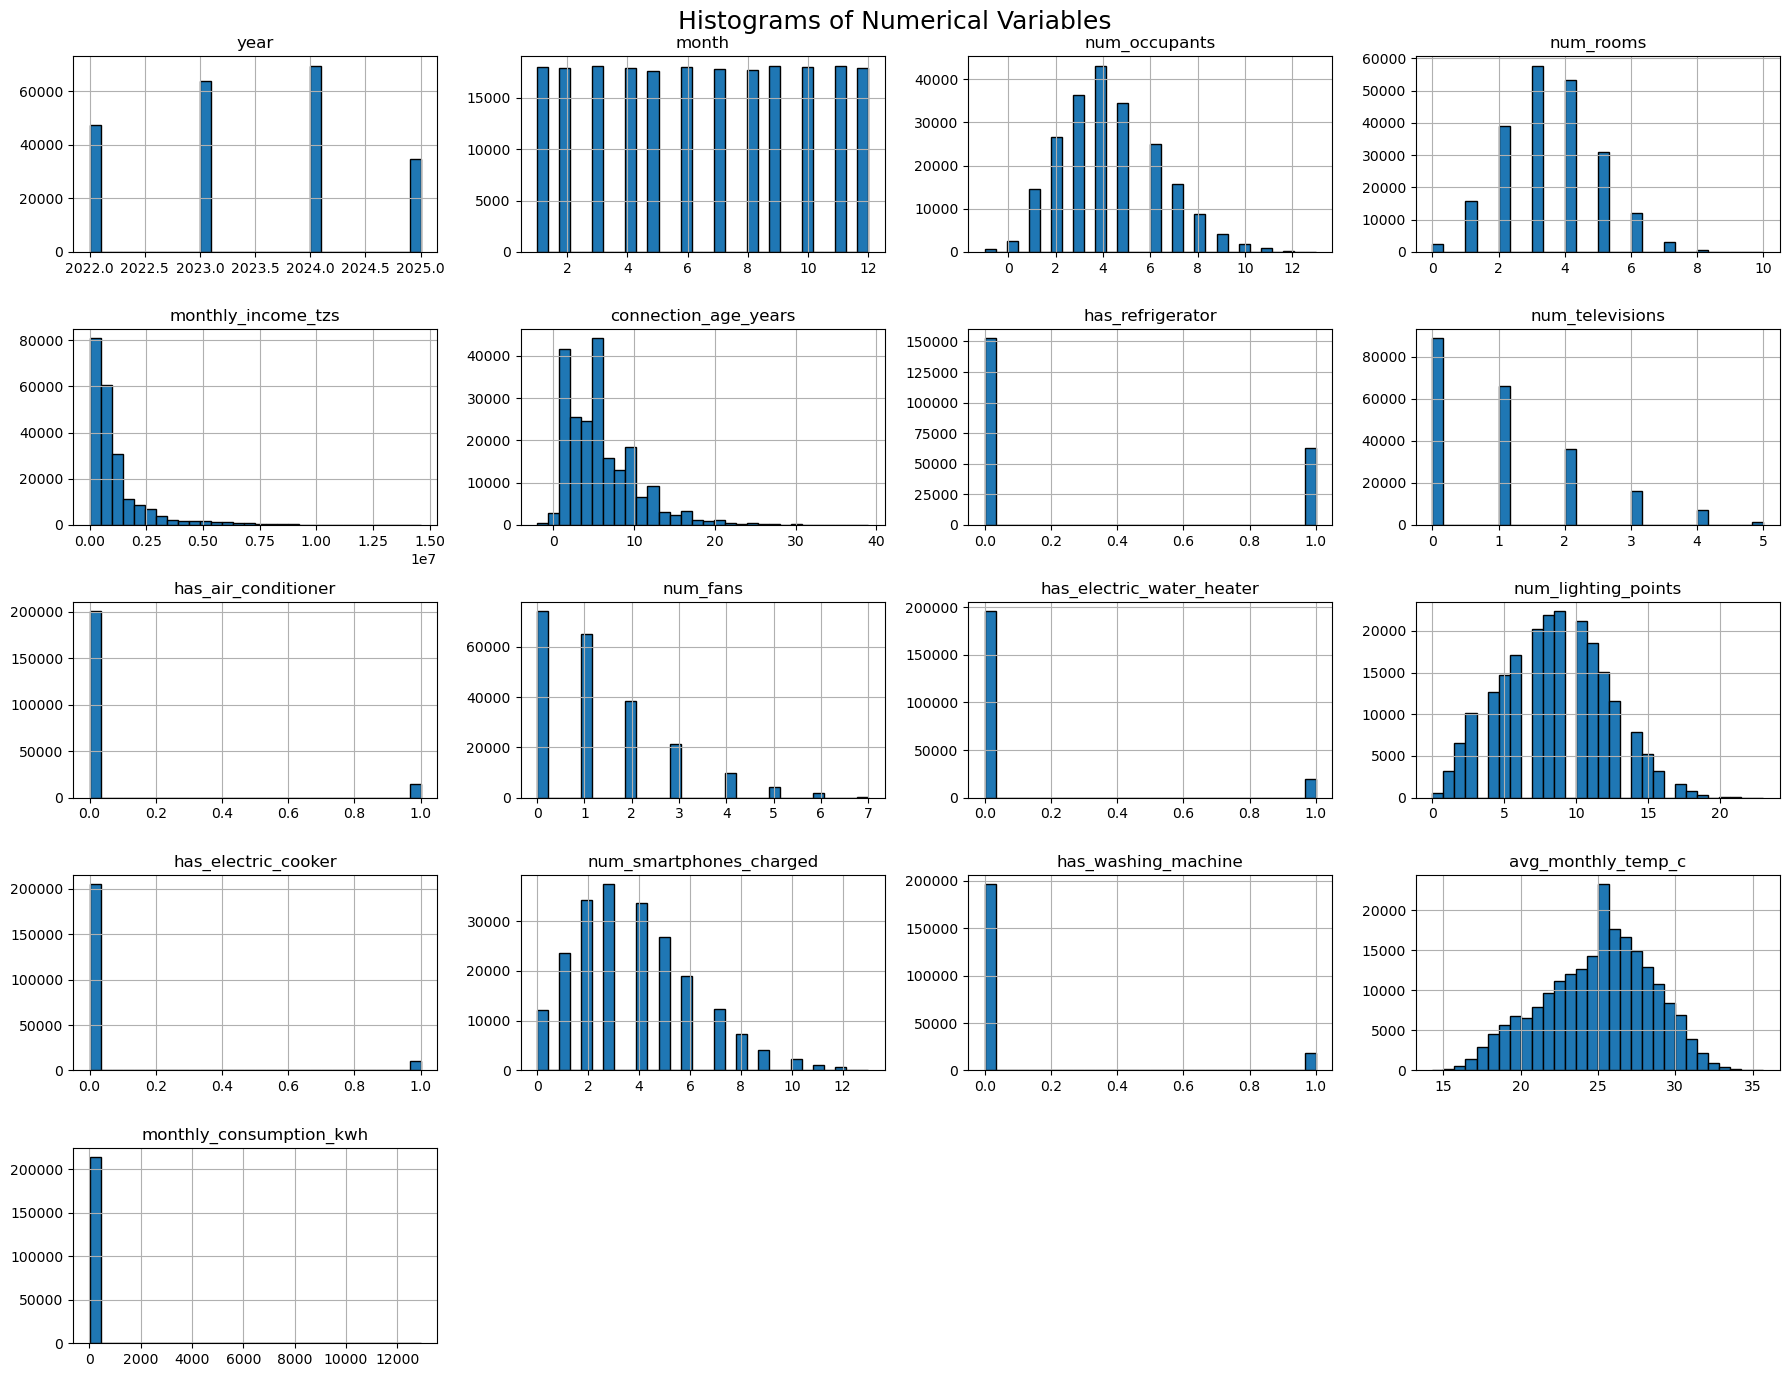

In [19]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].hist(
    figsize=(18,14),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Histograms of Numerical Variables", fontsize=18)
plt.tight_layout()
plt.show()

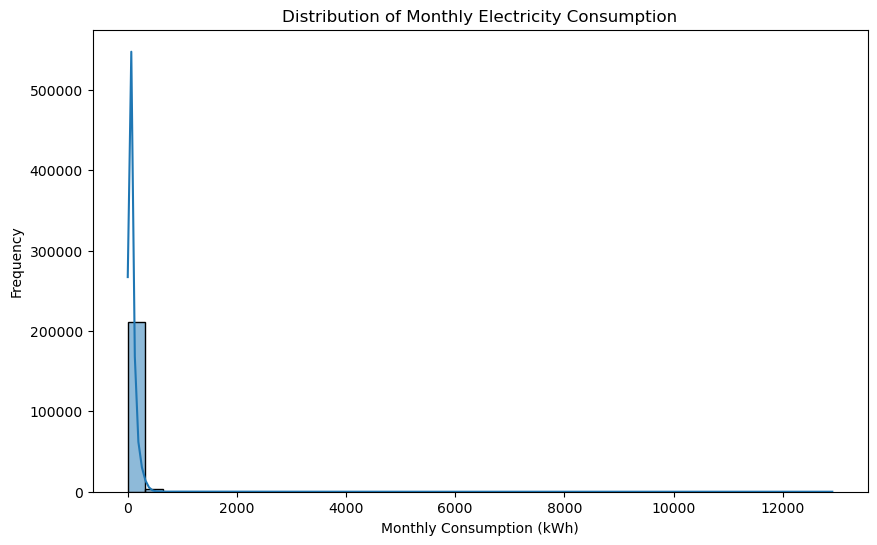

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["monthly_consumption_kwh"],
    bins=40,
    kde=True
)

plt.title("Distribution of Monthly Electricity Consumption")
plt.xlabel("Monthly Consumption (kWh)")
plt.ylabel("Frequency")
plt.show()

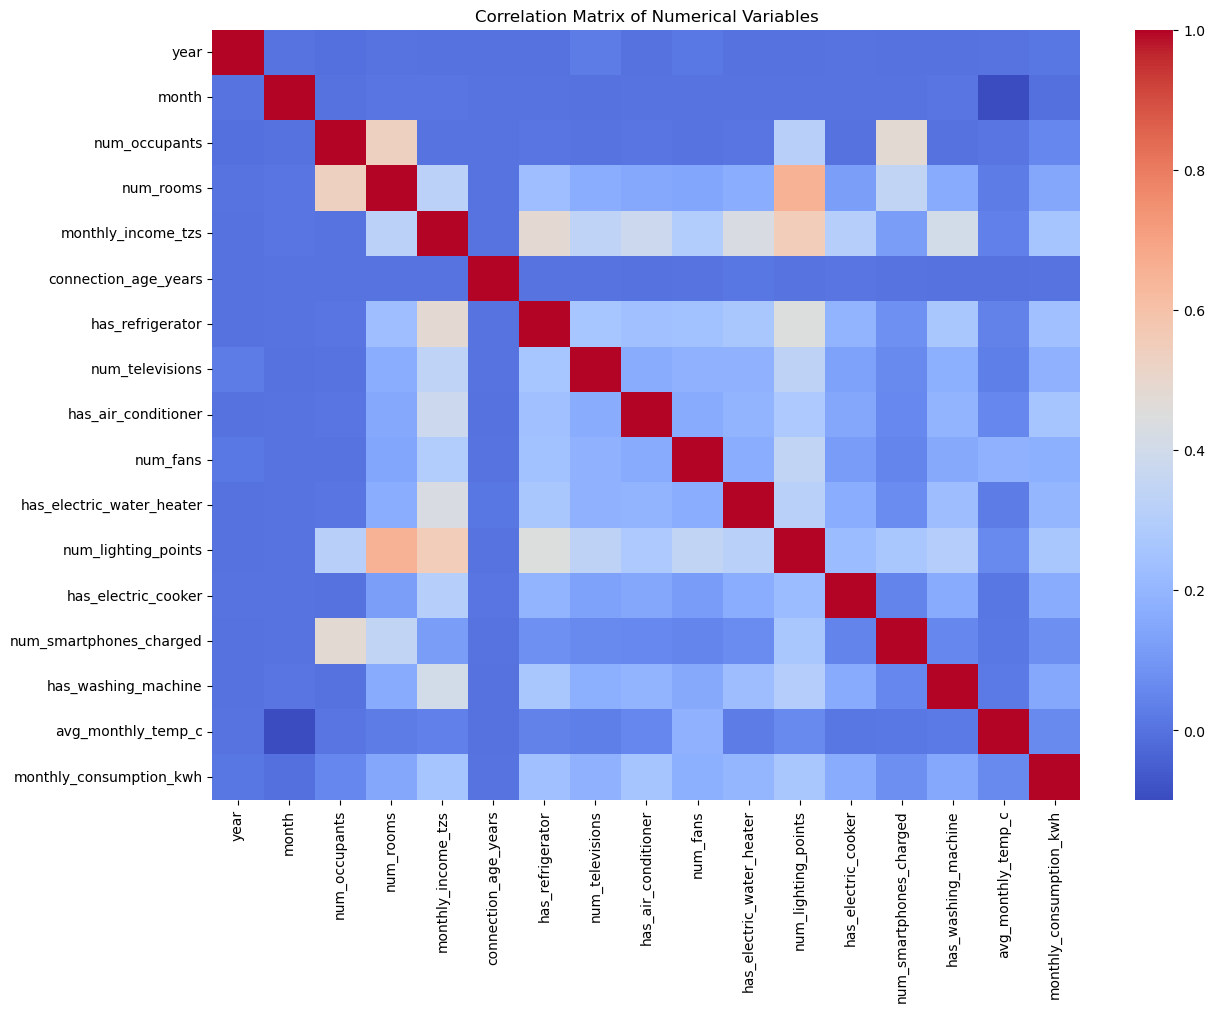

In [21]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [22]:
#Outliers

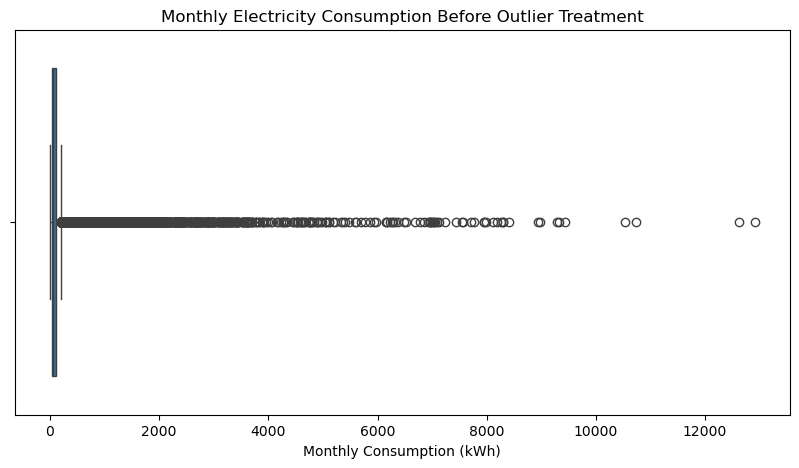

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["monthly_consumption_kwh"])

plt.title("Monthly Electricity Consumption Before Outlier Treatment")
plt.xlabel("Monthly Consumption (kWh)")
plt.show()

In [24]:
Q1 = df["monthly_consumption_kwh"].quantile(0.25)
Q3 = df["monthly_consumption_kwh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -63.10000000000001
Upper Bound: 206.5


In [25]:
outliers = df[
    (df["monthly_consumption_kwh"] < lower_bound) |
    (df["monthly_consumption_kwh"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 14890


In [26]:
df = df[
    (df["monthly_consumption_kwh"] >= lower_bound) &
    (df["monthly_consumption_kwh"] <= upper_bound)
]

print(df.shape)

(200257, 26)


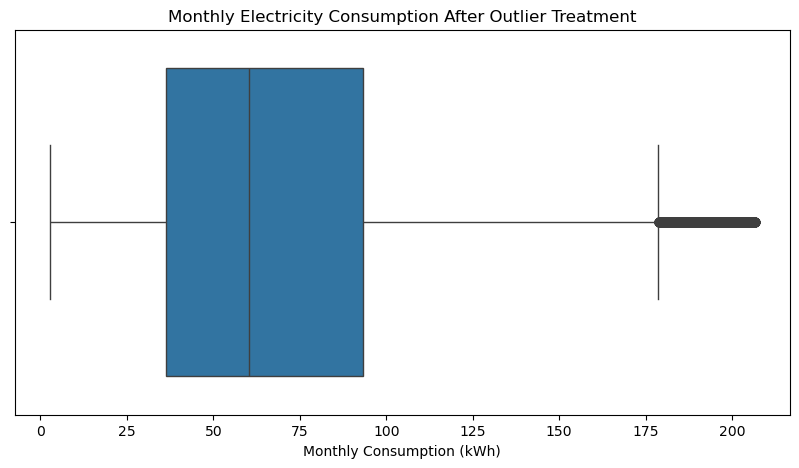

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["monthly_consumption_kwh"])

plt.title("Monthly Electricity Consumption After Outlier Treatment")
plt.xlabel("Monthly Consumption (kWh)")
plt.show()

In [28]:
#FEATURE ENGINEERING

In [38]:
# Total appliances
df["total_appliances"] = (
    df["has_refrigerator"] +
    df["num_televisions"] +
    df["has_air_conditioner"] +
    df["num_fans"] +
    df["has_electric_water_heater"] +
    df["has_electric_cooker"] +
    df["has_washing_machine"]
)

# Engineered Feature 1: Electricity Infrastructure Score
df["electricity_infrastructure"] = (
    df["num_rooms"] +
    df["num_lighting_points"] +
    df["total_appliances"]
)

# Engineered Feature 2: Household Activity Score
df["household_activity"] = (
    df["num_occupants"] *
    df["total_appliances"]
)

# Engineered Feature 3: Wealth Indicator
df["wealth_indicator"] = (
    df["monthly_income_tzs"] *
    (df["total_appliances"] + 1)
)

df.head()


,household_id,region,area_type,year,month,season,num_occupants,num_rooms,dwelling_type,income_band,...,appliances_per_room,lighting_per_room,income_per_person,rooms_per_person,ownership_score,comfort_score,lighting_density,electricity_infrastructure,household_activity,wealth_indicator
0,TZ-HH-000001,Morogoro,Rural,2022,10,Cool Dry,3.0,4,Swahili House (Shared),Upper-Middle,...,0.75,3.25,875000.000000,1.333333,1.0,1,4.333333,20.0,9.0,10500000.0
1,TZ-HH-000002,Arusha,Rural,2024,5,Long Rains,2.0,2,Swahili House (Shared),Low,...,1.50,2.00,74500.000000,1.000000,0.0,0,2.000000,9.0,6.0,596000.0
2,TZ-HH-000003,Zanzibar Urban/West,Urban,2024,11,Short Rains,6.0,4,Swahili House (Shared),Lower-Middle,...,0.50,2.50,139500.000000,0.666667,0.0,0,1.666667,16.0,12.0,2511000.0
3,TZ-HH-000004,Tanga,Urban,2024,5,Long Rains,4.0,4,Single-Family House,Middle,...,1.75,2.25,237500.000000,1.000000,1.0,1,2.250000,20.0,28.0,7600000.0
5,TZ-HH-000006,Tabora,Rural,2024,11,Short Rains,6.0,5,Swahili House (Shared),Lower-Middle,...,0.00,2.00,84333.333333,0.833333,0.0,0,1.666667,15.0,0.0,506000.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the engineered dataset
df_encoded = df.copy()

label_encoder = LabelEncoder()

categorical_columns = df_encoded.select_dtypes(include="object").columns

for column in categorical_columns:
    df_encoded[column] = label_encoder.fit_transform(
        df_encoded[column].astype(str)
    )

print(df_encoded.shape)
df_encoded.head()

In [31]:
#FEATURE IMPORTANCE

In [ ]:
# Separate predictors and target
X = df_encoded.drop(columns=["monthly_consumption_kwh"])
y = df_encoded["monthly_consumption_kwh"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
30,ownership_score,0.562867
33,electricity_infrastructure,0.128375
11,connection_type,0.070830
34,household_activity,0.058738
24,avg_monthly_temp_c,0.016363
17,has_air_conditioner,0.016122
0,household_id,0.014190
31,comfort_score,0.011772
25,total_appliances,0.010288
2,area_type,0.008885


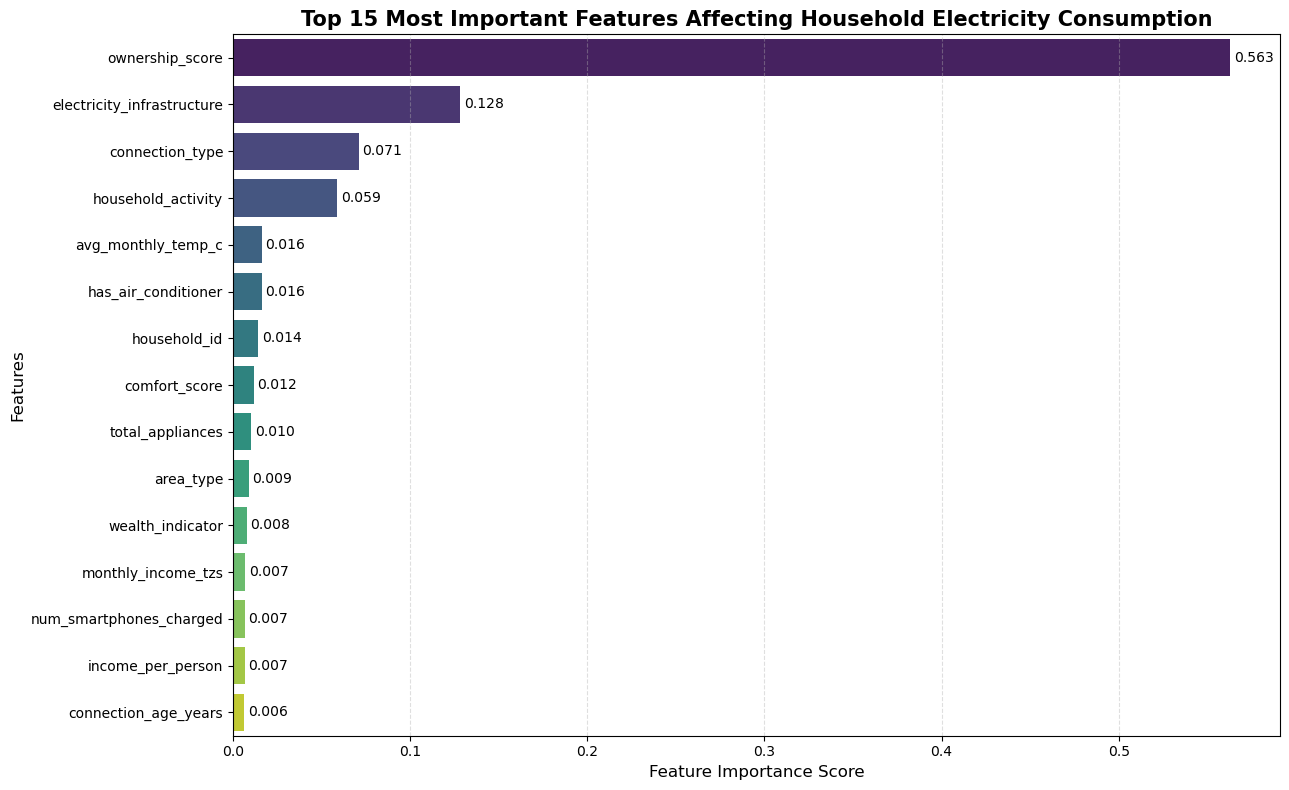

In [50]:
plt.figure(figsize=(13,8))

top_features = feature_importance.head(15)

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

# Display importance values
for i, value in enumerate(top_features["Importance"]):
    ax.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Most Important Features Affecting Household Electricity Consumption",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
df_encoded.to_csv(
    "electricity_consumption_processed_60_percent.csv",
    index=False
)

print("Dataset saved successfully.")